Using **Fraud Email Dataset** from https://www.kaggle.com/datasets/llabhishekll/fraud-email-dataset to create a subset for demonstration in our AI enhanced keyword searching project. This is a labeled dataset which comprises of multiple fraud emails and non-fraudulent emails.

**Acknowledgements:**
Radev, D. (2008), CLAIR collection of fraud email, ACL Data and Code Repository, ADCR2008T001, http://aclweb.org/aclwiki

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("/content/fraud_email_[1].csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11929 entries, 0 to 11928
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Text    11928 non-null  object
 1   Class   11929 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 186.5+ KB


Drop the class column and replace with email_id which is the unique identifier for each email in the corpus.

As the data is for demonstration, email_id will be filled by auto-incrementing from 1 to 1000 sequentially.

/tmp/ipykernel_7598/187957253.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['email_id'] = range(1, len(df_new)+1)


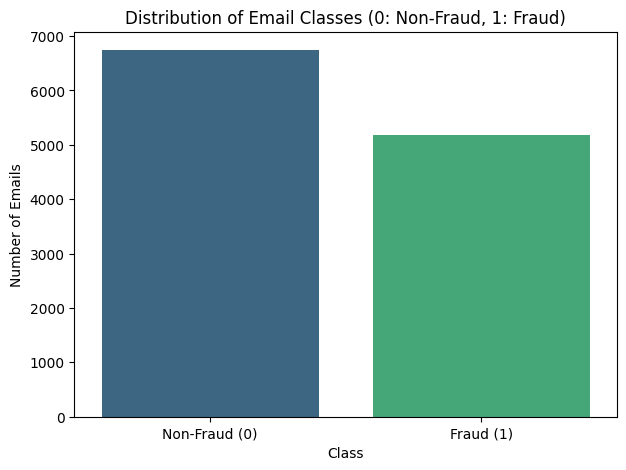

In [29]:
#Take a subset of the first 1000 rows
df_new = df.head(1000)

#Add email_id with auto-incrementing
df_new['email_id'] = range(1, len(df_new)+1)

#View class distribution
class_counts = df['Class'].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Email Classes (0: Non-Fraud, 1: Fraud)')
plt.xlabel('Class')
plt.ylabel('Number of Emails')
plt.xticks(ticks=[0, 1], labels=['Non-Fraud (0)', 'Fraud (1)'])
plt.show()


In [30]:
#Remove class column
df_new = df_new.drop(columns=['Class'])

#Reverse column order
df_new = df_new.iloc[:, ::-1]

#rename text to messages
df_new = df_new.rename(columns = {'Text':'messages'})

#Previe
df_new




,email_id,messages
0,1,Supply Quality China's EXCLUSIVE dimensions at...
1,2,over. SidLet me know. Thx.
2,3,"Dear Friend,Greetings to you.I wish to accost ..."
3,4,MR. CHEUNG PUIHANG SENG BANK LTD.DES VOEUX RD....
4,5,Not a surprising assessment from Embassy.
...,...,...
995,996,8:25 am PRESIDENTIAL DAILY BRIEFING8:30 am Sec...
996,997,We have given them windowns. As soon as you ar...
997,998,"Finally, You are hereby advised to indicate t..."
998,999,Mr=2E Fred Okoli Email=3A fred2okoli=40excite=...


Export df_new as fraud_emails.csv

In [26]:
df_new.to_csv("fraud_emails.csv")